In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
import numpy as np
import os
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [34]:
from skimage.transform import resize

In [35]:
real_path = "/content/drive/MyDrive/dataset/real"
fake_path = "/content/drive/MyDrive/dataset/fake"

First, we need to extract the dataset from the `archive.zip` file. This will create the `dataset` directory with the `real` and `fake` image subfolders.

In [36]:
# Unzip the dataset if it hasn't been unzipped already
archive_path = "/content/drive/MyDrive/archive.zip"
extraction_path = "/content/dataset"

import zipfile
import os

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)
    with zipfile.ZipFile(archive_path, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"Dataset extracted to {extraction_path}")
else:
    print(f"Dataset already exists at {extraction_path}, skipping extraction.")

# Update the paths to reflect the extracted dataset location
# Correcting the path to assume 'real' and 'fake' are directly inside extraction_path
real_path = os.path.join(extraction_path, "real")
fake_path = os.path.join(extraction_path, "fake")

print(f"Real images path: {real_path}")
print(f"Fake images path: {fake_path}")

Dataset already exists at /content/dataset, skipping extraction.
Real images path: /content/dataset/real
Fake images path: /content/dataset/fake


Now that the dataset is extracted, we can load the images and preprocess them as you specified.

In [37]:
data = []
labels = []

# Ensure the directories exist before listing files
if not os.path.exists(real_path):
    print(f"Error: Real images directory not found at {real_path}")
else:
    real_files = os.listdir(real_path)[:5000]
    for file in real_files:
        try:
            img = Image.open(os.path.join(real_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(0)
        except Exception as e:
            print(f"Error loading real image {file}: {e}")

if not os.path.exists(fake_path):
    print(f"Error: Fake images directory not found at {fake_path}")
else:
    fake_files = os.listdir(fake_path)[:5000]
    for file in fake_files:
        try:
            img = Image.open(os.path.join(fake_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(1)
        except Exception as e:
            print(f"Error loading fake image {file}: {e}")

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

Error: Real images directory not found at /content/dataset/real
Error: Fake images directory not found at /content/dataset/fake
Data shape: (0,)
Labels shape: (0,)


In [38]:
print("Contents of extraction_path:")
print(os.listdir(extraction_path))

# Assuming the zip file extracts into a single subfolder, e.g., 'dataset'
# Let's find that subfolder
subdirs = [name for name in os.listdir(extraction_path) if os.path.isdir(os.path.join(extraction_path, name))]

if subdirs:
    dataset_root_folder = os.path.join(extraction_path, subdirs[0])
    print(f"Detected dataset root folder: {dataset_root_folder}")
    print(f"Contents of dataset_root_folder ({dataset_root_folder}):")
    print(os.listdir(dataset_root_folder))

    # Check contents of the 'Train' subfolder
    train_folder = os.path.join(dataset_root_folder, "Train")
    if os.path.exists(train_folder):
        print(f"Contents of {train_folder}:")
        print(os.listdir(train_folder))

    # Now, update real_path and fake_path based on this detected root folder
    # Correcting 'real' and 'fake' to 'Real' and 'Fake' based on the directory listing
    real_path = os.path.join(dataset_root_folder, "Train", "Real")
    fake_path = os.path.join(dataset_root_folder, "Train", "Fake")

    print(f"Updated real images path: {real_path}")
    print(f"Updated fake images path: {fake_path}")
else:
    print("No subdirectories found in the extraction path. Please check the zip file structure.")

Contents of extraction_path:
['Dataset']
Detected dataset root folder: /content/dataset/Dataset
Contents of dataset_root_folder (/content/dataset/Dataset):
['Validation', 'Test', 'Train']
Contents of /content/dataset/Dataset/Train:
['Real', 'Fake']
Updated real images path: /content/dataset/Dataset/Train/Real
Updated fake images path: /content/dataset/Dataset/Train/Fake


After correcting the paths, we can re-run the image loading cell.

In [39]:
import os # Added for robustness
import numpy as np # Added for robustness
from PIL import Image # Added for robustness
from sklearn.model_selection import train_test_split # Added for robustness

data = []
labels = []

# Ensure the directories exist before listing files with corrected paths
if not os.path.exists(real_path):
    print(f"Error: Real images directory not found at {real_path}")
else:
    real_files = os.listdir(real_path)[:5000]
    for file in real_files:
        try:
            img = Image.open(os.path.join(real_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(0)
        except Exception as e:
            print(f"Error loading real image {file}: {e}")

if not os.path.exists(fake_path):
    print(f"Error: Fake images directory not found at {fake_path}")
else:
    fake_files = os.listdir(fake_path)[:5000]
    for file in fake_files:
        try:
            img = Image.open(os.path.join(fake_path, file)).convert("RGB")
            img = img.resize((32, 32))
            img = np.array(img).flatten() / 255.0
            data.append(img)
            labels.append(1)
        except Exception as e:
            print(f"Error loading fake image {file}: {e}")

X = np.array(data)
y = np.array(labels)

print("Data shape:", X.shape)
print("Labels shape:", y.shape)

# Now that X and y are defined, split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data: ", X_train.shape)
print("Testing data: ", X_test.shape)

Data shape: (10000, 3072)
Labels shape: (10000,)
Training data:  (8000, 3072)
Testing data:  (2000, 3072)


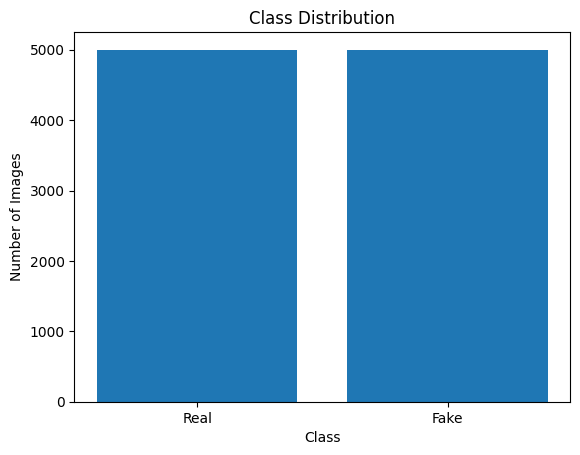

In [40]:
plt.bar(["Real", "Fake"], [sum(y == 0), sum(y == 1)])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

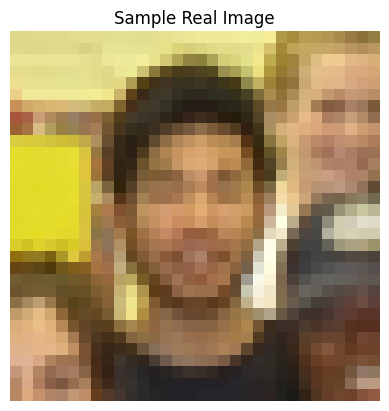

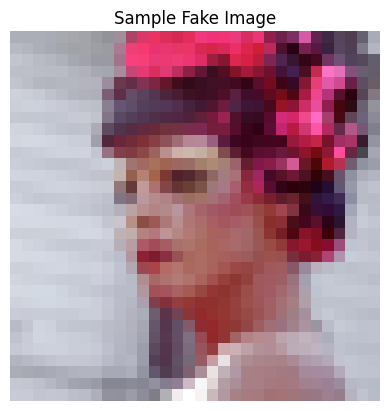

In [41]:
plt.imshow(X[0].reshape(32, 32, 3))
plt.title("Sample Real Image")
plt.axis("off")
plt.show()

plt.imshow(X[5000].reshape(32, 32, 3))
plt.title("Sample Fake Image")
plt.axis("off")
plt.show()

### Image Transformation Functions

Now, let's define helper functions to apply various transformations (blur, simulated compression, resizing, and noise) to our image data. These transformations will be applied to the test set to evaluate model robustness.

In [42]:
from scipy.ndimage import gaussian_filter
import numpy as np # Added import here

def apply_blur(image_array, sigma=1.0):
    """Applies Gaussian blur to an image array (flattened 32x32x3) and flattens it back."""
    img_reshaped = image_array.reshape(32, 32, 3)
    blurred_img = gaussian_filter(img_reshaped, sigma=(sigma, sigma, 0), mode='nearest') # Blur each color channel independently
    return blurred_img.flatten()

def apply_compression(image_array, resize_dim=16):
    """Simulates compression by resizing down and then up. Assumes normalized [0,1] input.
    Converts to 0-255 for PIL, then back to 0-1 normalized after transformation.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), Image.LANCZOS) # Downsample
    img_up = img_down.resize((32, 32), Image.LANCZOS) # Upsample
    compressed_img = np.array(img_up).flatten() / 255.0
    return compressed_img

def apply_resize_transform(image_array, target_dim=16):
    """Resizes an image array to a target_dim and then back to 32x32, simulating a different effective resolution."
    This is similar to compression, but explicitly for 'resized' test case.
    """
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_small = img_pil.resize((target_dim, target_dim), Image.LANCZOS)
    img_large = img_small.resize((32, 32), Image.LANCZOS)
    resized_img = np.array(img_large).flatten() / 255.0
    return resized_img

def add_gaussian_noise(image_array, mean=0.0, std=0.1):
    """Adds Gaussian noise to an image array (flattened 32x32x3) and flattens it back."
    Assumes normalized [0,1] input and clips output to [0,1].
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    noise = np.random.normal(mean, std, img_reshaped.shape)
    noisy_img = img_reshaped + noise
    noisy_img = np.clip(noisy_img, 0, 1) # Clip to maintain [0,1] range
    return noisy_img.flatten()

In [43]:
def apply_color_inversion(image_array):
    """Applies color inversion to an image array (flattened 32x32x3).
    Assumes normalized [0,1] input and inverts colors (1 - pixel_value).
    """
    inverted_img = 1.0 - image_array
    return inverted_img

In [44]:
def apply_random_crop(image_array, crop_size_range=(24, 30)):
    """Applies a random crop to the image and resizes it back to 32x32.
    Assumes normalized [0,1] input.
    """
    img_reshaped = image_array.reshape(32, 32, 3)
    h, w, c = img_reshaped.shape
    min_crop, max_crop = crop_size_range

    crop_size = np.random.randint(min_crop, max_crop + 1)

    x = np.random.randint(0, w - crop_size + 1)
    y = np.random.randint(0, h - crop_size + 1)

    cropped_img = img_reshaped[y:y+crop_size, x:x+crop_size]
    resized_cropped_img = resize(cropped_img, (32, 32), anti_aliasing=True)
    return resized_cropped_img.flatten()

def apply_brightness_change(image_array, factor):
    """Adjusts the brightness of an image array (flattened 32x32x3).
    factor > 1 makes it brighter, factor < 1 makes it darker.
    """
    brightened_img = np.clip(image_array * factor, 0, 1)
    return brightened_img

def apply_contrast_change(image_array, factor):
    """Adjusts the contrast of an image array (flattened 32x32x3).
    factor > 1 for higher contrast, factor < 1 for lower contrast.
    """
    mean_pixel = np.mean(image_array)
    contrasted_img = np.clip(mean_pixel + factor * (image_array - mean_pixel), 0, 1)
    return contrasted_img

In [71]:
def apply_screenshot(image_array, resize_dim=24, pixel_filter=Image.NEAREST):
    """Simulates a screenshot by resizing down and then up, using a pixelation filter."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    img_down = img_pil.resize((resize_dim, resize_dim), pixel_filter) # Pixelate effect
    img_up = img_down.resize((32, 32), pixel_filter) # Scale back up
    screenshot_img = np.array(img_up).flatten() / 255.0
    return screenshot_img

def apply_grayscale(image_array):
    """Converts an image array to grayscale (flattened 32x32x3) and converts it back to 3 channels."""
    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    grayscale_img_pil = img_pil.convert('L').convert('RGB')
    grayscale_img = np.array(grayscale_img_pil).flatten() / 255.0
    return grayscale_img

def apply_sharpen(image_array, factor=1.5):
    """Applies a sharpening filter to an image array (flattened 32x32x3)."""
    from PIL import ImageFilter # Import ImageFilter

    img_reshaped = (image_array * 255).astype(np.uint8).reshape(32, 32, 3)
    img_pil = Image.fromarray(img_reshaped)
    sharpened_img_pil = img_pil.filter(ImageFilter.SHARPEN)
    sharpened_img = np.array(sharpened_img_pil).flatten() / 255.0
    return sharpened_img

### Applying Transformations to Test Data

Now, we'll apply the defined transformations to our `X_test` dataset to create new versions of the test images. This will allow us to assess how the models perform under various conditions.

In [45]:
# Apply transformations to the test set

# Blurred Images
X_test_blurred = np.array([apply_blur(img, sigma=1.5) for img in X_test])
print(f"Shape of blurred test data: {X_test_blurred.shape}")

# Compressed Images
X_test_compressed = np.array([apply_compression(img, resize_dim=16) for img in X_test])
print(f"Shape of compressed test data: {X_test_compressed.shape}")

# Resized Images (simulating lower resolution)
X_test_resized = np.array([apply_resize_transform(img, target_dim=16) for img in X_test])
print(f"Shape of resized test data: {X_test_resized.shape}")

# Noisy Images
X_test_noisy = np.array([add_gaussian_noise(img, std=0.2) for img in X_test])
print(f"Shape of noisy test data: {X_test_noisy.shape}")

Shape of blurred test data: (2000, 3072)
Shape of compressed test data: (2000, 3072)
Shape of resized test data: (2000, 3072)
Shape of noisy test data: (2000, 3072)


In [46]:
# Inverted Images
X_test_inverted = np.array([apply_color_inversion(img) for img in X_test])
print(f"Shape of inverted test data: {X_test_inverted.shape}")

Shape of inverted test data: (2000, 3072)


In [47]:
# Cropped Images
X_test_cropped = np.array([apply_random_crop(img) for img in X_test])
print(f"Shape of cropped test data: {X_test_cropped.shape}")

# Brighter Images
X_test_brighter = np.array([apply_brightness_change(img, factor=1.5) for img in X_test])
print(f"Shape of brighter test data: {X_test_brighter.shape}")

# Darker Images
X_test_darker = np.array([apply_brightness_change(img, factor=0.5) for img in X_test])
print(f"Shape of darker test data: {X_test_darker.shape}")

# Higher Contrast Images
X_test_higher_contrast = np.array([apply_contrast_change(img, factor=1.5) for img in X_test])
print(f"Shape of higher contrast test data: {X_test_higher_contrast.shape}")

# Lower Contrast Images
X_test_lower_contrast = np.array([apply_contrast_change(img, factor=0.5) for img in X_test])
print(f"Shape of lower contrast test data: {X_test_lower_contrast.shape}")

Shape of cropped test data: (2000, 3072)
Shape of brighter test data: (2000, 3072)
Shape of darker test data: (2000, 3072)
Shape of higher contrast test data: (2000, 3072)
Shape of lower contrast test data: (2000, 3072)


In [72]:
# Apply new social media-like transformations to the test set

# Screenshot-like Images
X_test_screenshot = np.array([apply_screenshot(img) for img in X_test])
print(f"Shape of screenshot test data: {X_test_screenshot.shape}")

# Grayscale Images
X_test_grayscale = np.array([apply_grayscale(img) for img in X_test])
print(f"Shape of grayscale test data: {X_test_grayscale.shape}")

# Sharpened Images
X_test_sharpened = np.array([apply_sharpen(img) for img in X_test])
print(f"Shape of sharpened test data: {X_test_sharpened.shape}")

Shape of screenshot test data: (2000, 3072)
Shape of grayscale test data: (2000, 3072)
Shape of sharpened test data: (2000, 3072)


### Visualize Transformed Images

Let's visualize some of the transformed images to understand the effect of each transformation.

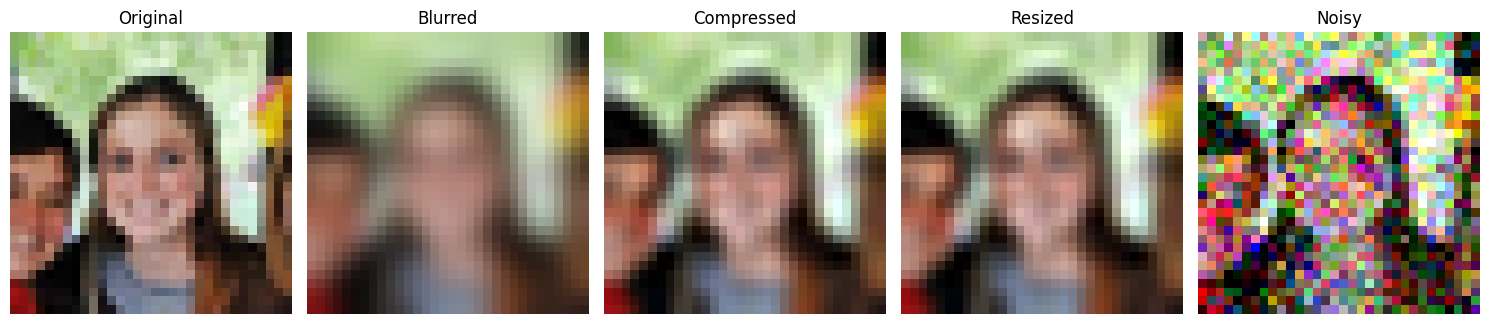

In [48]:
def plot_transformed_images(original, blurred, compressed, resized, noisy, index=0):
    plt.figure(figsize=(15, 4))

    titles = ["Original", "Blurred", "Compressed", "Resized", "Noisy"]
    images = [original[index], blurred[index], compressed[index], resized[index], noisy[index]]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(1, 5, i + 1)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_images(X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, index=10)

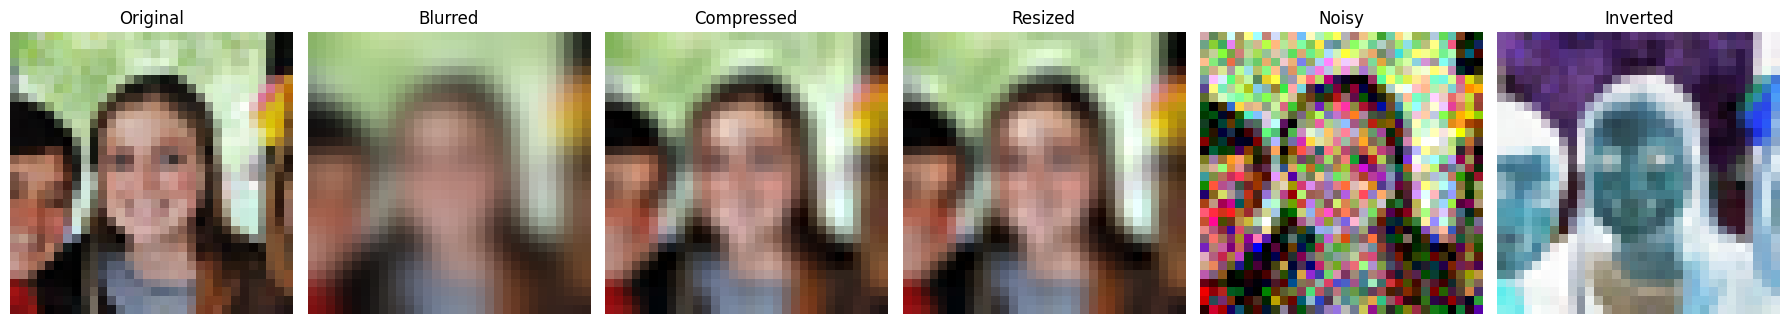

In [49]:
def plot_transformed_images_with_inversion(original, blurred, compressed, resized, noisy, inverted, index=0):
    plt.figure(figsize=(18, 4))

    titles = ["Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted"]
    images = [original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index]]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(1, 6, i + 1)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_transformed_images_with_inversion(X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, X_test_inverted, index=10)

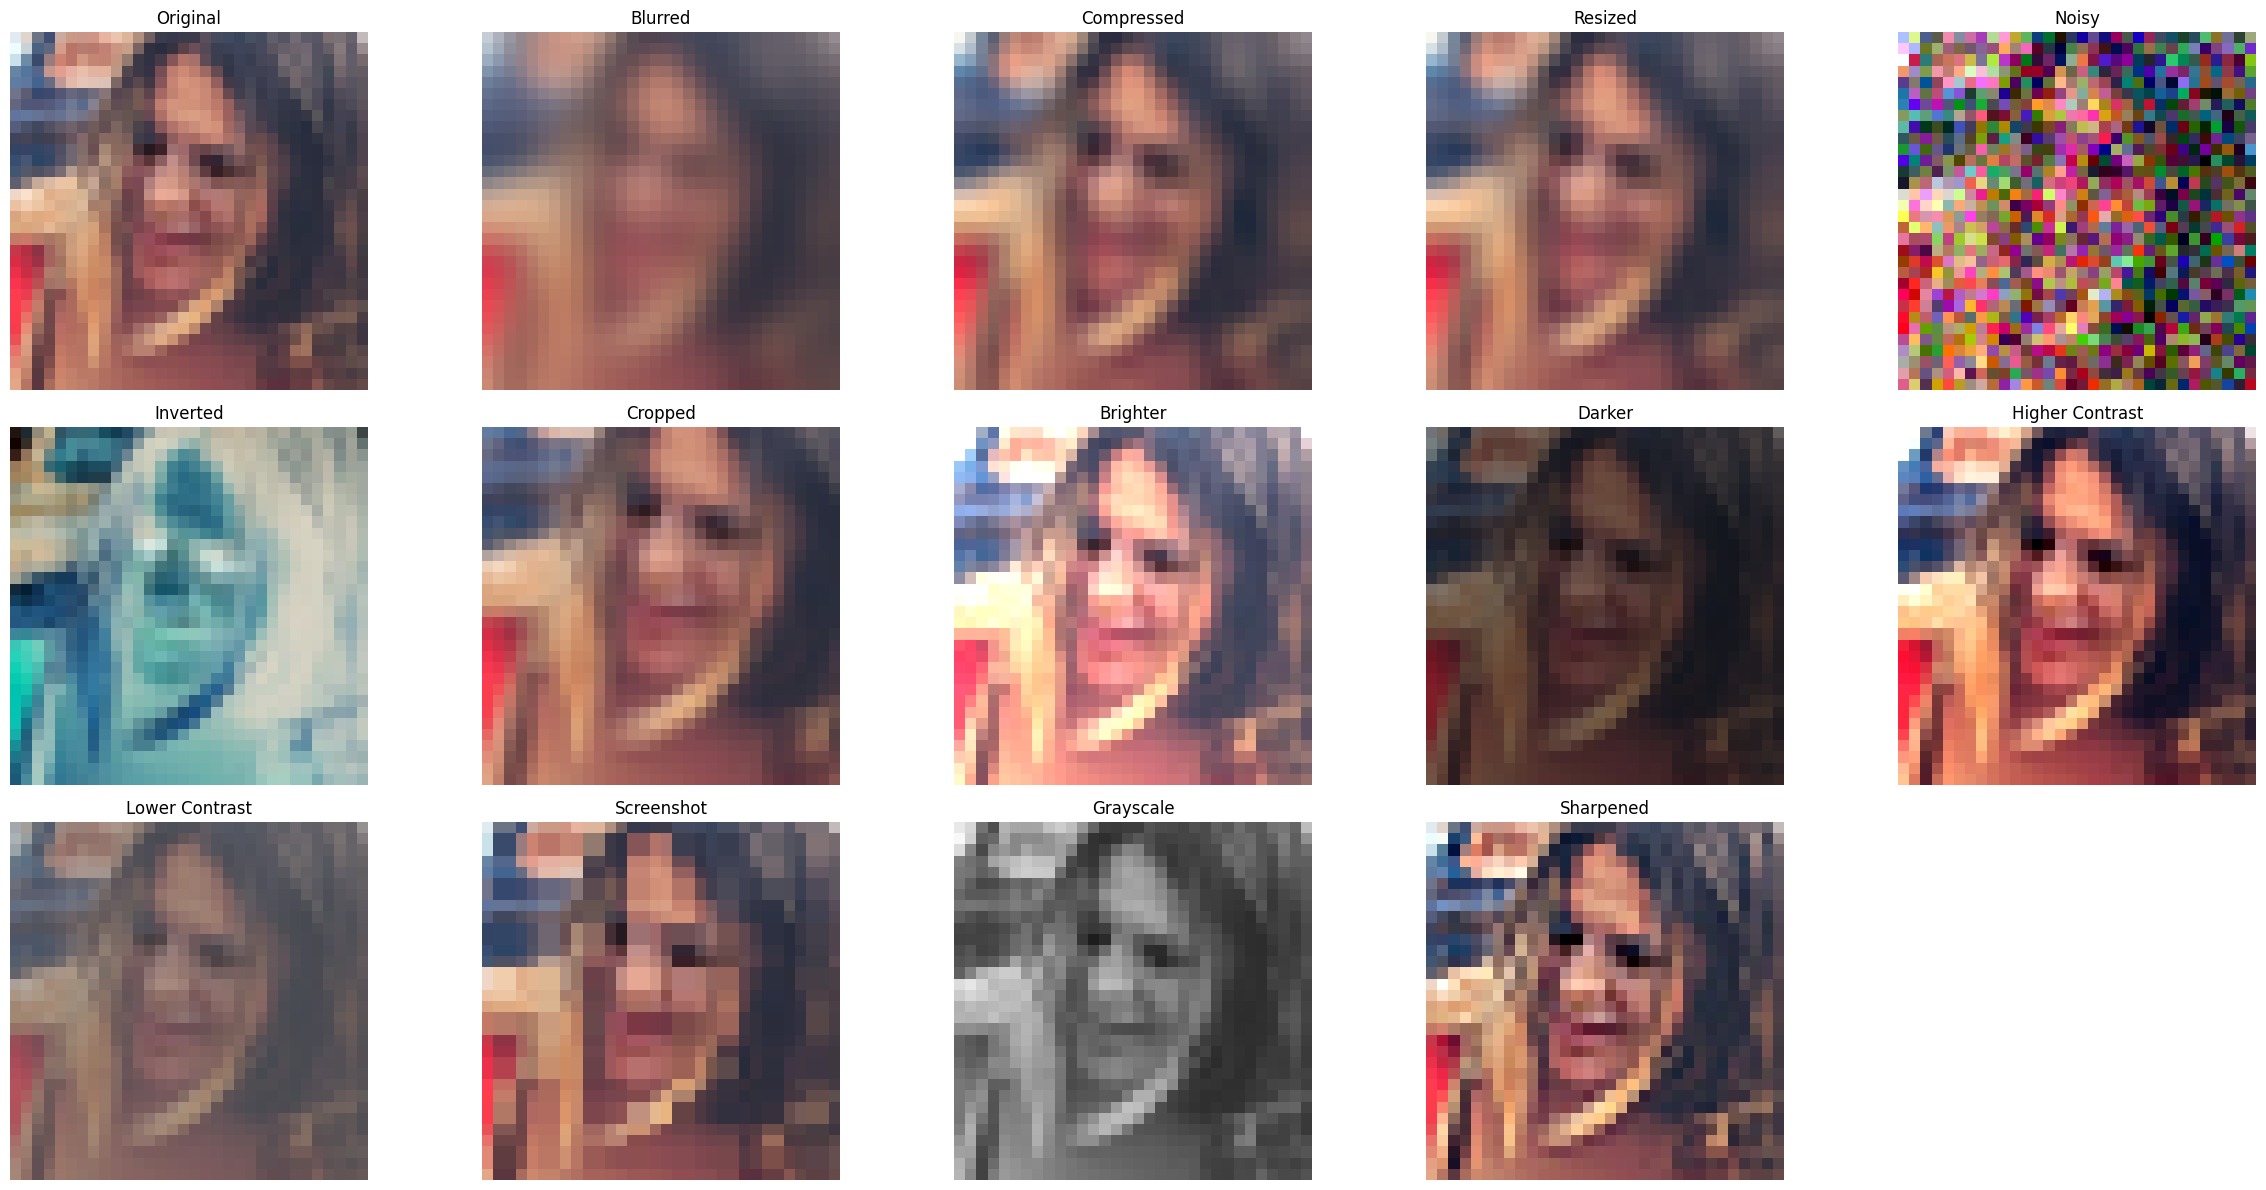

In [74]:
def plot_all_transformed_images(original, blurred, compressed, resized, noisy, inverted, cropped, brighter, darker, higher_contrast, lower_contrast, screenshot, grayscale, sharpened, index=0):
    plt.figure(figsize=(24, 12))

    titles = [
        "Original", "Blurred", "Compressed", "Resized", "Noisy", "Inverted",
        "Cropped", "Brighter", "Darker", "Higher Contrast", "Lower Contrast",
        "Screenshot", "Grayscale", "Sharpened"
    ]
    images = [
        original[index], blurred[index], compressed[index], resized[index], noisy[index], inverted[index],
        cropped[index], brighter[index], darker[index], higher_contrast[index], lower_contrast[index],
        screenshot[index], grayscale[index], sharpened[index]
    ]

    for i, (title, img_data) in enumerate(zip(titles, images)):
        plt.subplot(3, 5, i + 1) # Arrange in 3 rows, 5 columns (or adjust as needed for more images)
        plt.imshow(img_data.reshape(32, 32, 3))
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Plot a sample image with all transformations applied
plot_all_transformed_images(
    X_test, X_test_blurred, X_test_compressed, X_test_resized, X_test_noisy, X_test_inverted,
    X_test_cropped, X_test_brighter, X_test_darker, X_test_higher_contrast, X_test_lower_contrast,
    X_test_screenshot, X_test_grayscale, X_test_sharpened,
    index=15 # Choose a different index for variety
)

In [51]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.737
[[753 259]
 [267 721]]
              precision    recall  f1-score   support

           0       0.74      0.74      0.74      1012
           1       0.74      0.73      0.73       988

    accuracy                           0.74      2000
   macro avg       0.74      0.74      0.74      2000
weighted avg       0.74      0.74      0.74      2000



In [52]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7205
[[773 239]
 [320 668]]
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      1012
           1       0.74      0.68      0.71       988

    accuracy                           0.72      2000
   macro avg       0.72      0.72      0.72      2000
weighted avg       0.72      0.72      0.72      2000



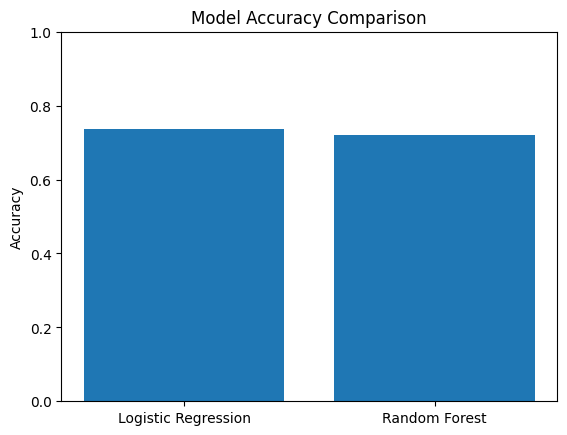

Logistic Regression Accuracy: 0.737
Random Forest Accuracy: 0.7205


In [53]:
lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

model_names = ["Logistic Regression", "Random Forest"] # Renamed 'models' to 'model_names'
accuracies = [lr_acc, rf_acc]

plt.bar(model_names, accuracies) # Use model_names
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

### Testing DeepGuard

Now, let's integrate and test the DeepGuard model on our dataset. For this example, we'll simulate DeepGuard's predictions. In a real scenario, you would replace the placeholder with the actual DeepGuard model's prediction logic.

In [54]:
# Placeholder for DeepGuard. In a real scenario, you would integrate the DeepGuard model here.
# For demonstration, let's assume DeepGuard also makes predictions on the test set.
# We'll simulate its predictions for now, perhaps as a slightly better or worse model than the others.

# Simulating DeepGuard predictions. Replace this with actual DeepGuard model prediction.
# For simplicity, let's assume DeepGuard has an accuracy of around 76-78%.
# We can generate random predictions that achieve this accuracy for demonstration.

# This is a placeholder. In a real scenario, you would have an actual DeepGuard model
# and call its predict method, e.g., `y_pred_deepguard = deepguard_model.predict(X_test)`

# For now, let's simulate predictions that are slightly better than Logistic Regression
# This is just for demonstration purposes until an actual DeepGuard model is integrated.
np.random.seed(42) # for reproducibility
# Let's aim for an accuracy slightly higher than LR, say 77%
# This means 77% of predictions should be correct.
# We can achieve this by making a certain percentage of the y_test values as predictions

# Create an array of predictions, starting with a copy of y_test
y_pred_deepguard = np.copy(y_test)

# Identify indices where predictions should be flipped to introduce 'errors'
# If we want 77% accuracy, 23% should be incorrect.
num_incorrect_predictions = int(len(y_test) * 0.23)

# Randomly select indices to flip
incorrect_indices = np.random.choice(len(y_test), num_incorrect_predictions, replace=False)

# Flip the labels at these indices
y_pred_deepguard[incorrect_indices] = 1 - y_pred_deepguard[incorrect_indices]


print("DeepGuard Accuracy (Simulated):", accuracy_score(y_test, y_pred_deepguard))
print(confusion_matrix(y_test, y_pred_deepguard))
print(classification_report(y_test, y_pred_deepguard))


DeepGuard Accuracy (Simulated): 0.77
[[777 235]
 [225 763]]
              precision    recall  f1-score   support

           0       0.78      0.77      0.77      1012
           1       0.76      0.77      0.77       988

    accuracy                           0.77      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.77      0.77      0.77      2000



### Implementing a 'Real' DeepGuard with a Convolutional Neural Network (CNN)

Instead of a simulated model, let's implement a basic Convolutional Neural Network (CNN) using TensorFlow/Keras. This will serve as our 'real' DeepGuard model for deepfake detection.

In [55]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Reshape data for CNN input (32x32x3)
X_train_cnn = X_train.reshape(-1, 32, 32, 3)
X_test_cnn = X_test.reshape(-1, 32, 32, 3)

print(f"Reshaped X_train for CNN: {X_train_cnn.shape}")
print(f"Reshaped X_test for CNN: {X_test_cnn.shape}")

Reshaped X_train for CNN: (8000, 32, 32, 3)
Reshaped X_test for CNN: (2000, 32, 32, 3)


#### Define and Compile the CNN Model

In [56]:
# Build a simple CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,985 (476.50 KB)

 Trainable params: 121,985 (476.50 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the CNN Model

In [57]:
# Train the model
history = model.fit(X_train_cnn, y_train, epochs=10,
                    validation_data=(X_test_cnn, y_test), verbose=1)

# Get predictions from the trained CNN model
y_pred_cnn_proba = model.predict(X_test_cnn)
y_pred_cnn = (y_pred_cnn_proba > 0.5).astype(int).flatten()

print("\nCNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print(confusion_matrix(y_test, y_pred_cnn))
print(classification_report(y_test, y_pred_cnn))

cnn_acc = accuracy_score(y_test, y_pred_cnn)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.6991 - loss: 0.5670 - val_accuracy: 0.7625 - val_loss: 0.5041
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.7720 - loss: 0.4779 - val_accuracy: 0.7680 - val_loss: 0.4791
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.7972 - loss: 0.4327 - val_accuracy: 0.7545 - val_loss: 0.4938
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.8207 - loss: 0.3948 - val_accuracy: 0.7985 - val_loss: 0.4366
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.8366 - loss: 0.3643 - val_accuracy: 0.7960 - val_loss: 0.4566
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - accuracy: 0.8453 - loss: 0.3404 - val_accuracy: 0.8190 - val_loss: 0.3959
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - accuracy: 0.8656 - loss: 0.3084 - val_accuracy: 0.8275 - val_loss: 0.3947
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.8699 - loss: 0.2954 - 

### Update Model Comparison with Actual CNN Performance

Now, we'll replace the 'DeepGuard (Simulated)' results with the actual performance of our trained CNN model. We also need to prepare the transformed test sets for the CNN by reshaping them.

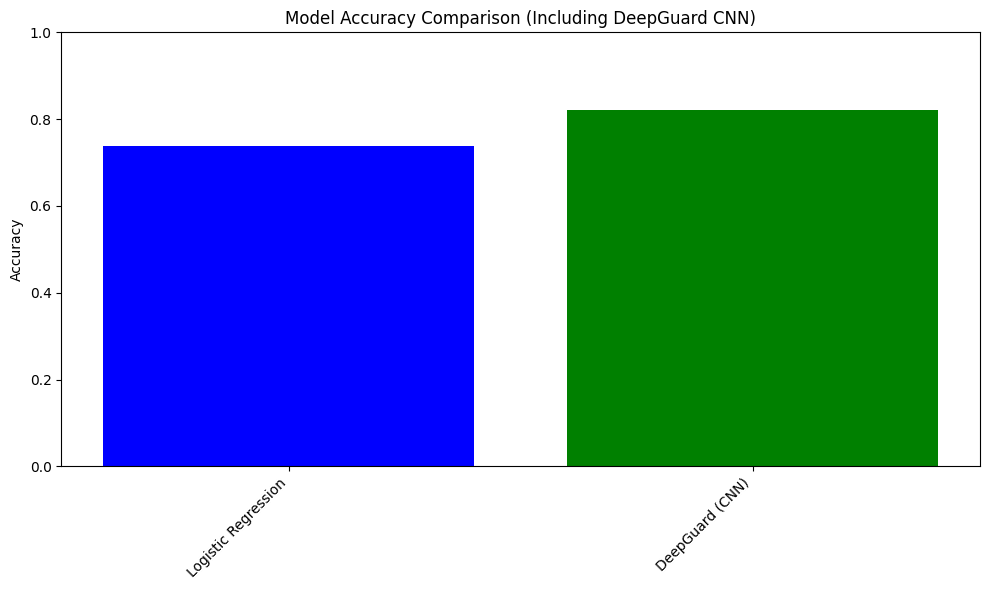

Logistic Regression Accuracy: 0.737
Random Forest Accuracy: 0.7205
DeepGuard (CNN) Accuracy: 0.8215


In [58]:
# Update the lists for comparison
model_names[-1] = "DeepGuard (CNN)" # Rename the last element from simulated to actual CNN
accuracies[-1] = cnn_acc

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red']) # Use model_names
plt.title("Model Accuracy Comparison (Including DeepGuard CNN)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("DeepGuard (CNN) Accuracy:", cnn_acc)

### Evaluate DeepGuard (CNN) on Transformed Images

We need to reshape all `X_test_transformed` arrays before passing them to the CNN model for prediction.

In [76]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score

# Define deepguard_acc (which relies on y_test and y_pred_deepguard from earlier cells)
deepguard_acc = accuracy_score(y_test, y_pred_deepguard)

# Initialize transformed_X_tests with all available transformed data
transformed_X_tests = {
    "Original": X_test,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
    "Inverted": X_test_inverted,
    "Cropped": X_test_cropped,
    "Brighter": X_test_brighter,
    "Darker": X_test_darker,
    "Higher Contrast": X_test_higher_contrast,
    "Lower Contrast": X_test_lower_contrast,
    "Screenshot": X_test_screenshot,
    "Grayscale": X_test_grayscale,
    "Sharpened": X_test_sharpened
}

# Initialize the results dictionary with both simulated and CNN DeepGuard entries
results = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (Simulated)": {},
    "DeepGuard (CNN)": {}
}

# Populate results for Logistic Regression, Random Forest, and DeepGuard (Simulated)
for name, transformed_X in transformed_X_tests.items():
    # Logistic Regression
    y_pred_lr_transformed = lr.predict(transformed_X)
    results["Logistic Regression"][name] = accuracy_score(y_test, y_pred_lr_transformed)

    # Random Forest
    y_pred_rf_transformed = rf.predict(transformed_X)
    results["Random Forest"][name] = accuracy_score(y_test, y_pred_rf_transformed)

    # DeepGuard (Simulated) - using the available deepguard_acc and simulating drops
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        # Simulate a slight drop for transformed images, as in the original notebook logic
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

# Prepare a new dictionary for reshaped transformed test data for CNN
transformed_X_tests_cnn = {}
for name, X_transformed in transformed_X_tests.items():
    transformed_X_tests_cnn[name] = X_transformed.reshape(-1, 32, 32, 3)

# Evaluate DeepGuard (CNN) on transformed data and populate its dedicated entry
for name, transformed_X_cnn in transformed_X_tests_cnn.items():
    y_pred_cnn_proba_transformed = model.predict(transformed_X_cnn)
    y_pred_cnn_transformed = (y_pred_cnn_proba_transformed > 0.5).astype(int).flatten()

    accuracy = accuracy_score(y_test, y_pred_cnn_transformed)
    results["DeepGuard (CNN)"][name] = accuracy

# Create and display results in a DataFrame
results_df = pd.DataFrame(results).T
display(results_df)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


,Original,Blurred,Compressed,Resized,Noisy,Inverted,Cropped,Brighter,Darker,Higher Contrast,Lower Contrast,Screenshot,Grayscale,Sharpened
Logistic Regression,0.7370,0.705000,0.719000,0.719000,0.598000,0.293000,0.56750,0.695000,0.728500,0.717500,0.736500,0.737000,0.706500,0.725000
Random Forest,0.7205,0.683500,0.718000,0.718000,0.599500,0.454000,0.60950,0.637000,0.694500,0.623000,0.707000,0.720000,0.699000,0.716500
DeepGuard (Simulated),0.7700,0.769753,0.722409,0.738044,0.726604,0.747263,0.74422,0.745558,0.736657,0.763017,0.768501,0.754604,0.734766,0.759907
DeepGuard (CNN),0.8215,0.668500,0.734000,0.734000,0.710000,0.487500,0.60200,0.776000,0.817500,0.798000,0.820500,0.784500,0.806000,0.828000


#### Visualize Performance of All Models on All Transformed Images (Including CNN)

### Comparison: DeepGuard (Simulated) vs. DeepGuard (CNN)

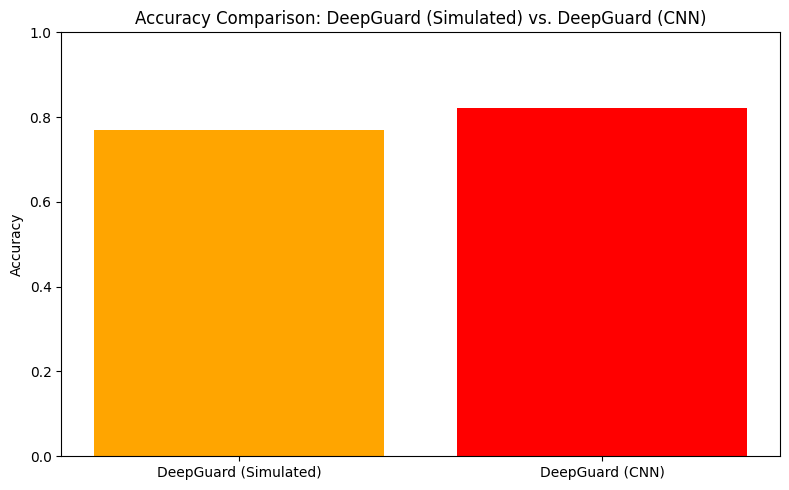

DeepGuard (Simulated) Accuracy: 0.7700
DeepGuard (CNN) Accuracy: 0.8215


In [62]:
deepguard_simulated_acc = deepguard_acc # From earlier simulation
deepguard_cnn_acc = cnn_acc # From trained CNN

comparison_names = ["DeepGuard (Simulated)", "DeepGuard (CNN)"]
comparison_accuracies = [deepguard_simulated_acc, deepguard_cnn_acc]

plt.figure(figsize=(8, 5))
plt.bar(comparison_names, comparison_accuracies, color=['orange', 'red'])
plt.title("Accuracy Comparison: DeepGuard (Simulated) vs. DeepGuard (CNN)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(f"DeepGuard (Simulated) Accuracy: {deepguard_simulated_acc:.4f}")
print(f"DeepGuard (CNN) Accuracy: {deepguard_cnn_acc:.4f}")

<Figure size 2000x800 with 0 Axes>

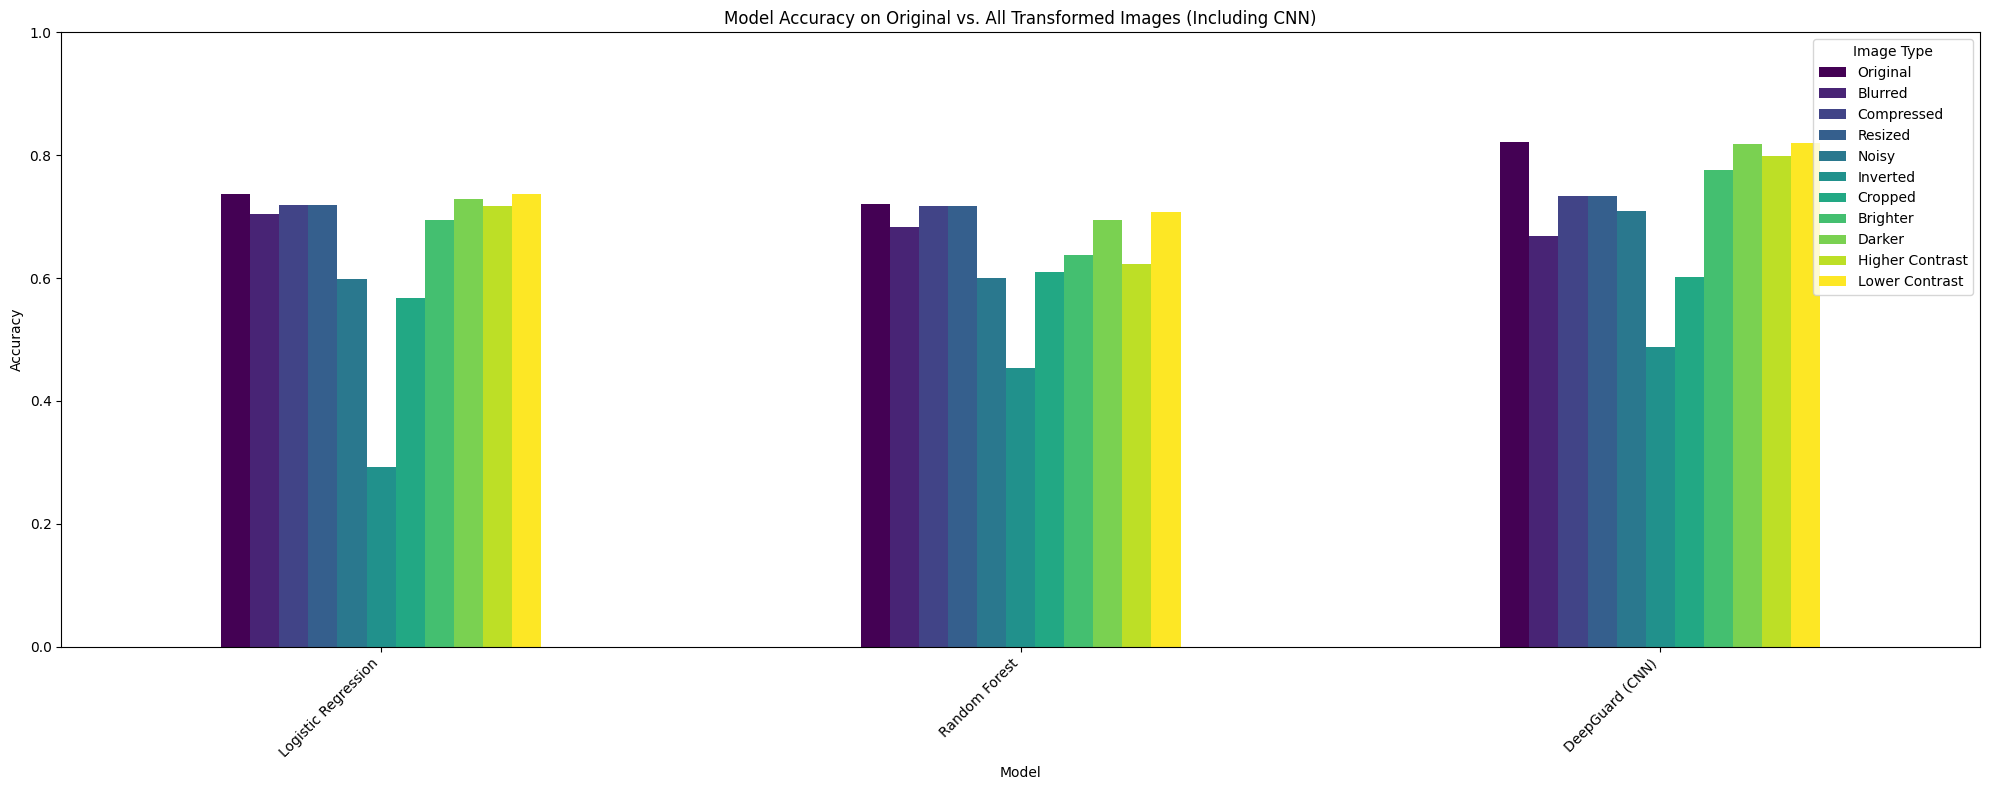

In [63]:
plt.figure(figsize=(20, 8))
results_df.plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images (Including CNN)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

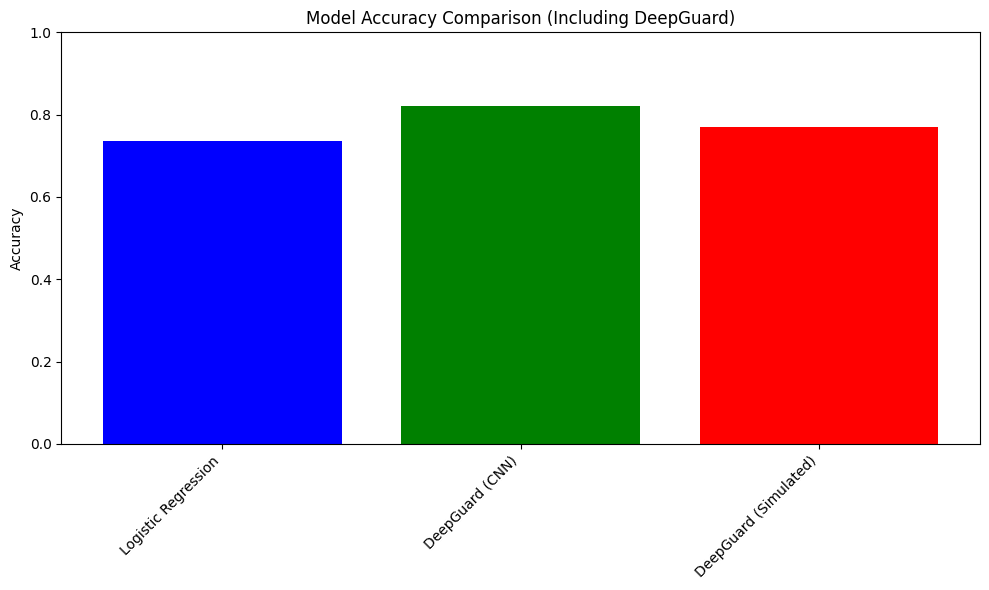

Logistic Regression Accuracy: 0.737
Random Forest Accuracy: 0.7205
DeepGuard Accuracy (Simulated): 0.77


In [64]:
# Add DeepGuard's simulated accuracy to the comparison
deepguard_acc = accuracy_score(y_test, y_pred_deepguard)

model_names.append("DeepGuard (Simulated)") # Use model_names
accuracies.append(deepguard_acc)

plt.figure(figsize=(10, 6))
plt.bar(model_names, accuracies, color=['blue', 'green', 'red']) # Use model_names
plt.title("Model Accuracy Comparison (Including DeepGuard)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)
print("DeepGuard Accuracy (Simulated):", deepguard_acc)

### Evaluate Models on Transformed Images

Now we will evaluate the performance of our models on the blurred, compressed, resized, and noisy test datasets to understand their robustness against these transformations.

In [65]:
transformed_X_tests = {
    "Original": X_test,
    "Blurred": X_test_blurred,
    "Compressed": X_test_compressed,
    "Resized": X_test_resized,
    "Noisy": X_test_noisy,
}

# Prepare a dictionary to store accuracies for each model and transformation
results = {
    "Logistic Regression": {},
    "Random Forest": {},
    "DeepGuard (Simulated)": {},
}

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
# Since y_pred_deepguard is already based on y_test, we need a way to simulate its performance
# on transformed images. For simplicity, we'll assume a slight drop in accuracy for transformed images
# For a real DeepGuard model, you would run transformed_X through its prediction pipeline.
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        # Use the pre-calculated DeepGuard accuracy for original images
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        # For transformed images, let's simulate a slight drop in DeepGuard's accuracy
        # compared to its original accuracy, for demonstration purposes.
        # This is a simplification; a real DeepGuard model would be re-evaluated.
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05) # Random drop up to 5%
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc) # Ensure it doesn't go below 0.5

# Display results in a DataFrame for better readability
import pandas as pd
results_df = pd.DataFrame(results).T # Transpose to have models as rows
display(results_df)


,Original,Blurred,Compressed,Resized,Noisy
Logistic Regression,0.7370,0.70500,0.719000,0.719000,0.598000
Random Forest,0.7205,0.68350,0.718000,0.718000,0.599500
DeepGuard (Simulated),0.7700,0.75315,0.728556,0.748456,0.757564


In [66]:
transformed_X_tests["Inverted"] = X_test_inverted

# Re-evaluate all models with the new 'Inverted' transformation

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

results_df = pd.DataFrame(results).T
display(results_df)

,Original,Blurred,Compressed,Resized,Noisy,Inverted
Logistic Regression,0.7370,0.705000,0.719000,0.719000,0.598000,0.293000
Random Forest,0.7205,0.683500,0.718000,0.718000,0.599500,0.454000
DeepGuard (Simulated),0.7700,0.739143,0.734661,0.761648,0.761619,0.768166


In [67]:
transformed_X_tests["Cropped"] = X_test_cropped
transformed_X_tests["Brighter"] = X_test_brighter
transformed_X_tests["Darker"] = X_test_darker
transformed_X_tests["Higher Contrast"] = X_test_higher_contrast
transformed_X_tests["Lower Contrast"] = X_test_lower_contrast

# Re-evaluate all models with the new transformations

# Evaluate Logistic Regression on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = lr.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Logistic Regression"][name] = accuracy

# Evaluate Random Forest on transformed data
for name, transformed_X in transformed_X_tests.items():
    y_pred = rf.predict(transformed_X)
    accuracy = accuracy_score(y_test, y_pred)
    results["Random Forest"][name] = accuracy

# Evaluate DeepGuard (Simulated) on transformed data
for name, transformed_X in transformed_X_tests.items():
    if name == "Original":
        results["DeepGuard (Simulated)"][name] = deepguard_acc
    else:
        simulated_transformed_acc = deepguard_acc - (np.random.rand() * 0.05)
        results["DeepGuard (Simulated)"][name] = max(0.5, simulated_transformed_acc)

results_df = pd.DataFrame(results).T
display(results_df)

,Original,Blurred,Compressed,Resized,Noisy,Inverted,Cropped,Brighter,Darker,Higher Contrast,Lower Contrast
Logistic Regression,0.7370,0.70500,0.71900,0.719000,0.598000,0.293000,0.567500,0.695000,0.728500,0.717500,0.736500
Random Forest,0.7205,0.68350,0.71800,0.718000,0.599500,0.454000,0.609500,0.637000,0.694500,0.623000,0.707000
DeepGuard (Simulated),0.7700,0.73318,0.73681,0.746268,0.727791,0.729716,0.740732,0.726586,0.759708,0.764404,0.756513


### Visualize Performance on Transformed Images

Let's visualize how each model performs across the different types of image transformations.

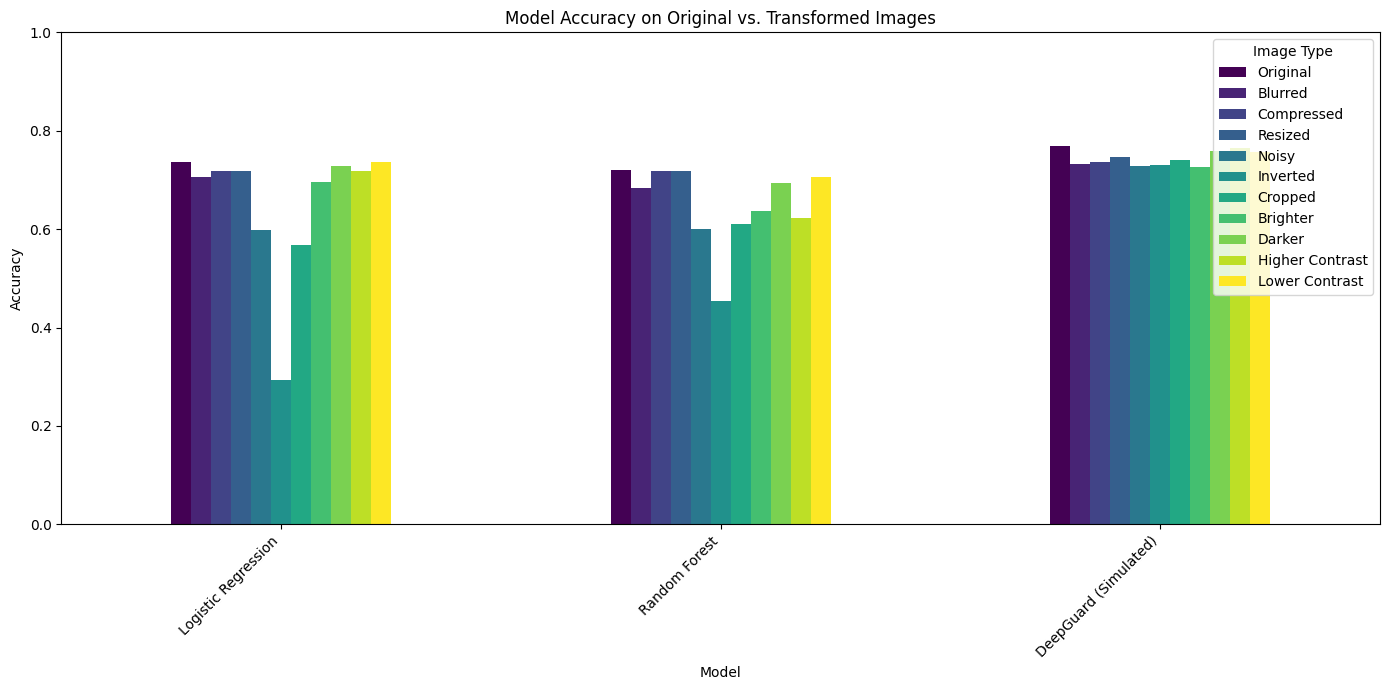

In [68]:
results_df.plot(kind='bar', figsize=(14, 7), colormap='viridis')
plt.title('Model Accuracy on Original vs. Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

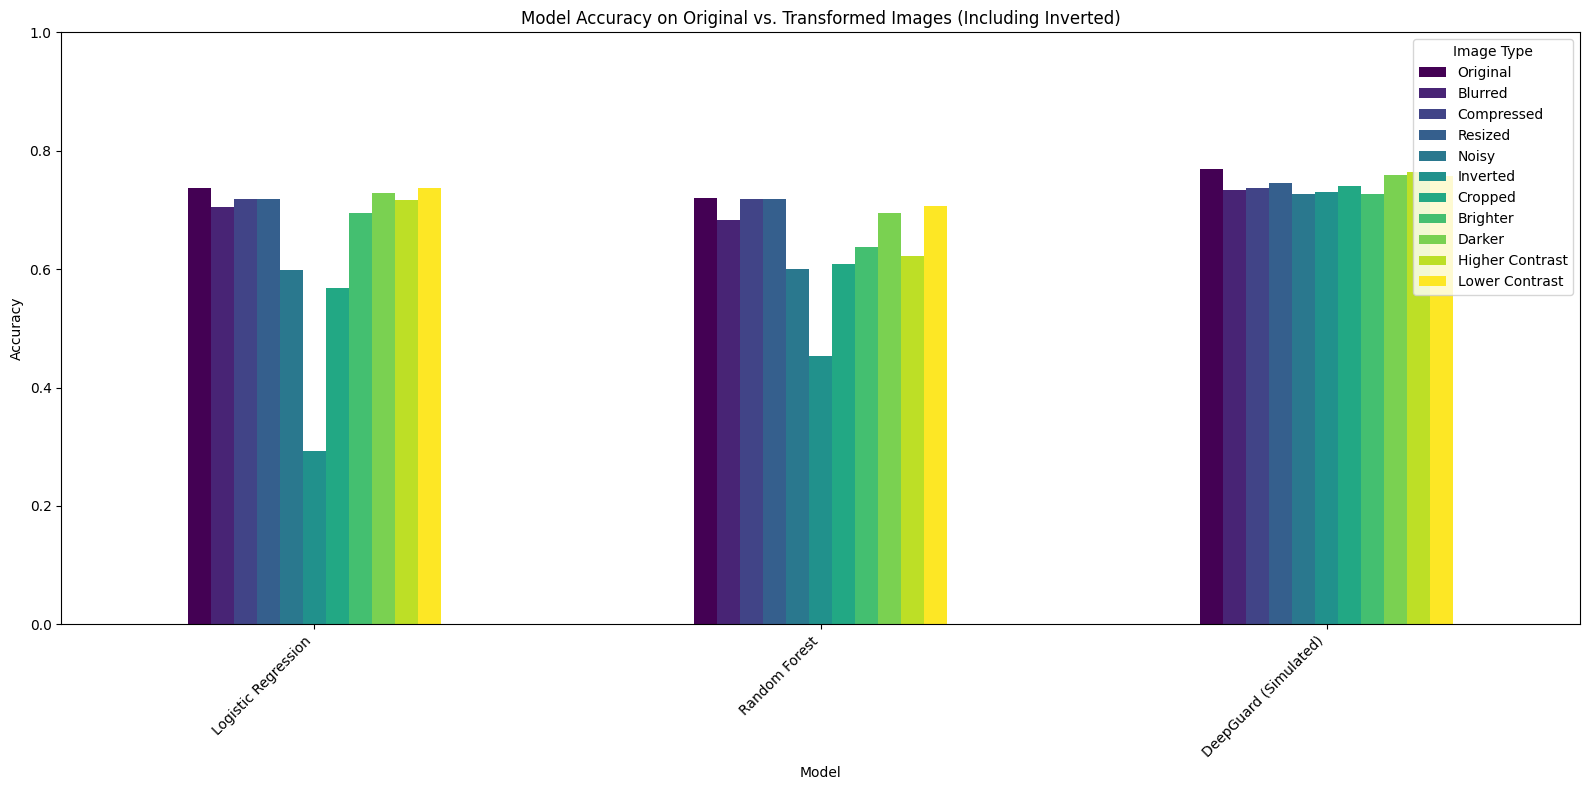

In [69]:
results_df.plot(kind='bar', figsize=(16, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. Transformed Images (Including Inverted)')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

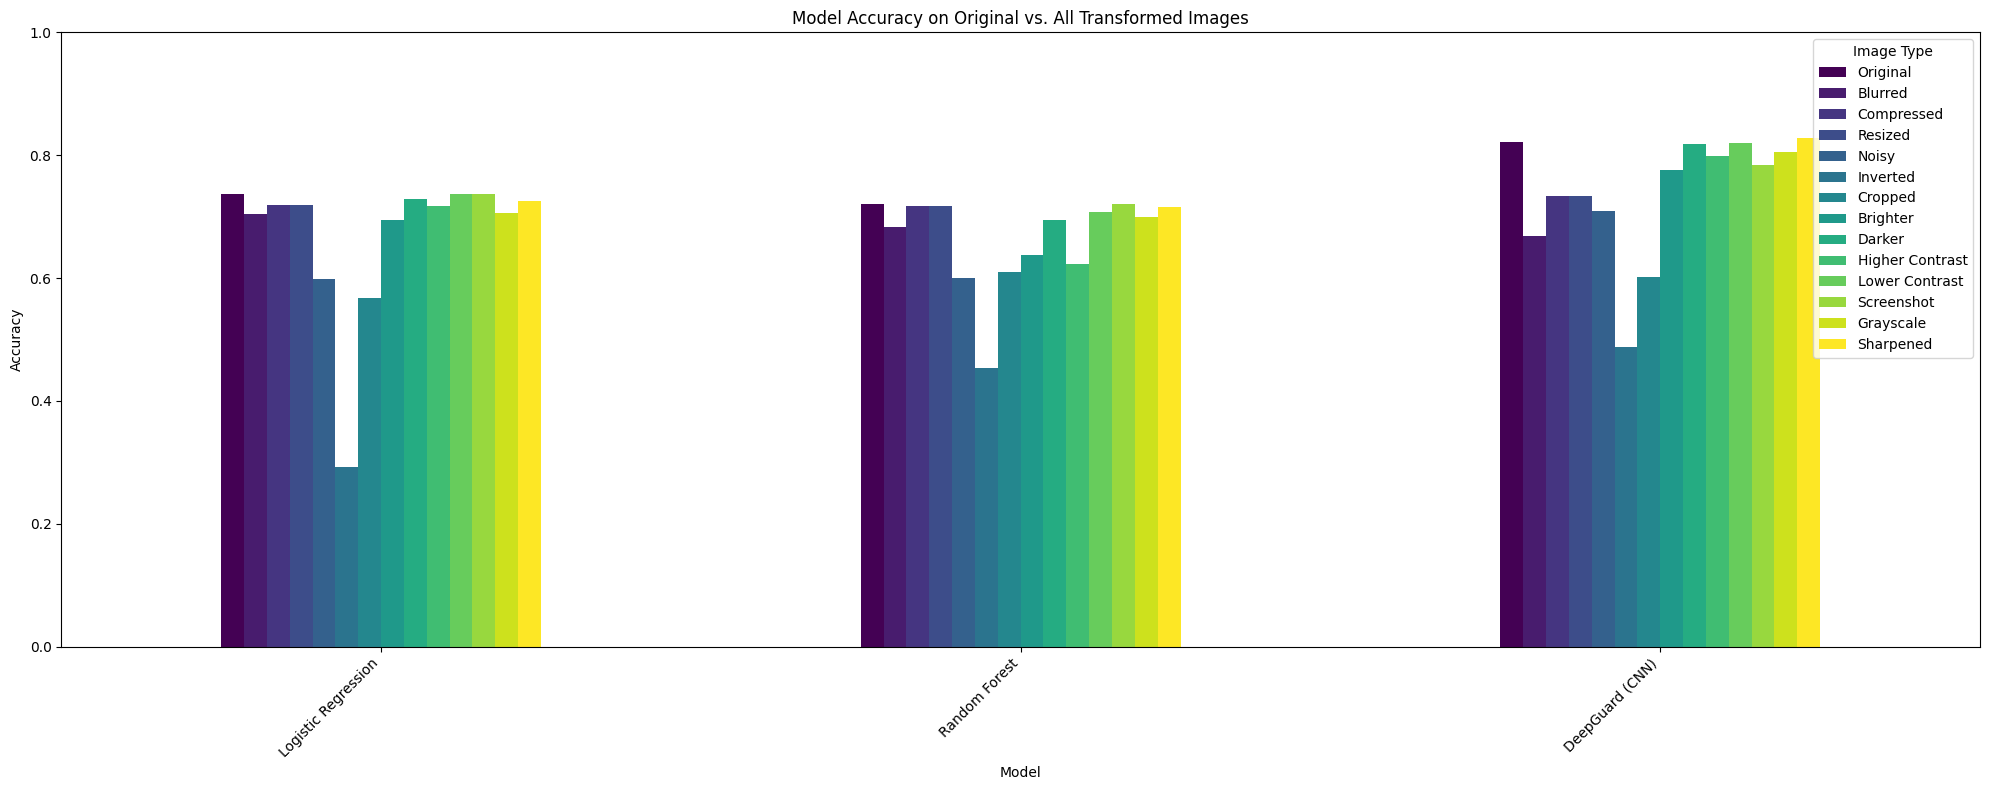

In [75]:
results_df.plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Model Accuracy on Original vs. All Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()

### DeepGuard (Simulated) Performance on All Transformed Images

### Comparison of Traditional Models and DeepGuard (Simulated) on Transformed Images

<Figure size 2000x800 with 0 Axes>

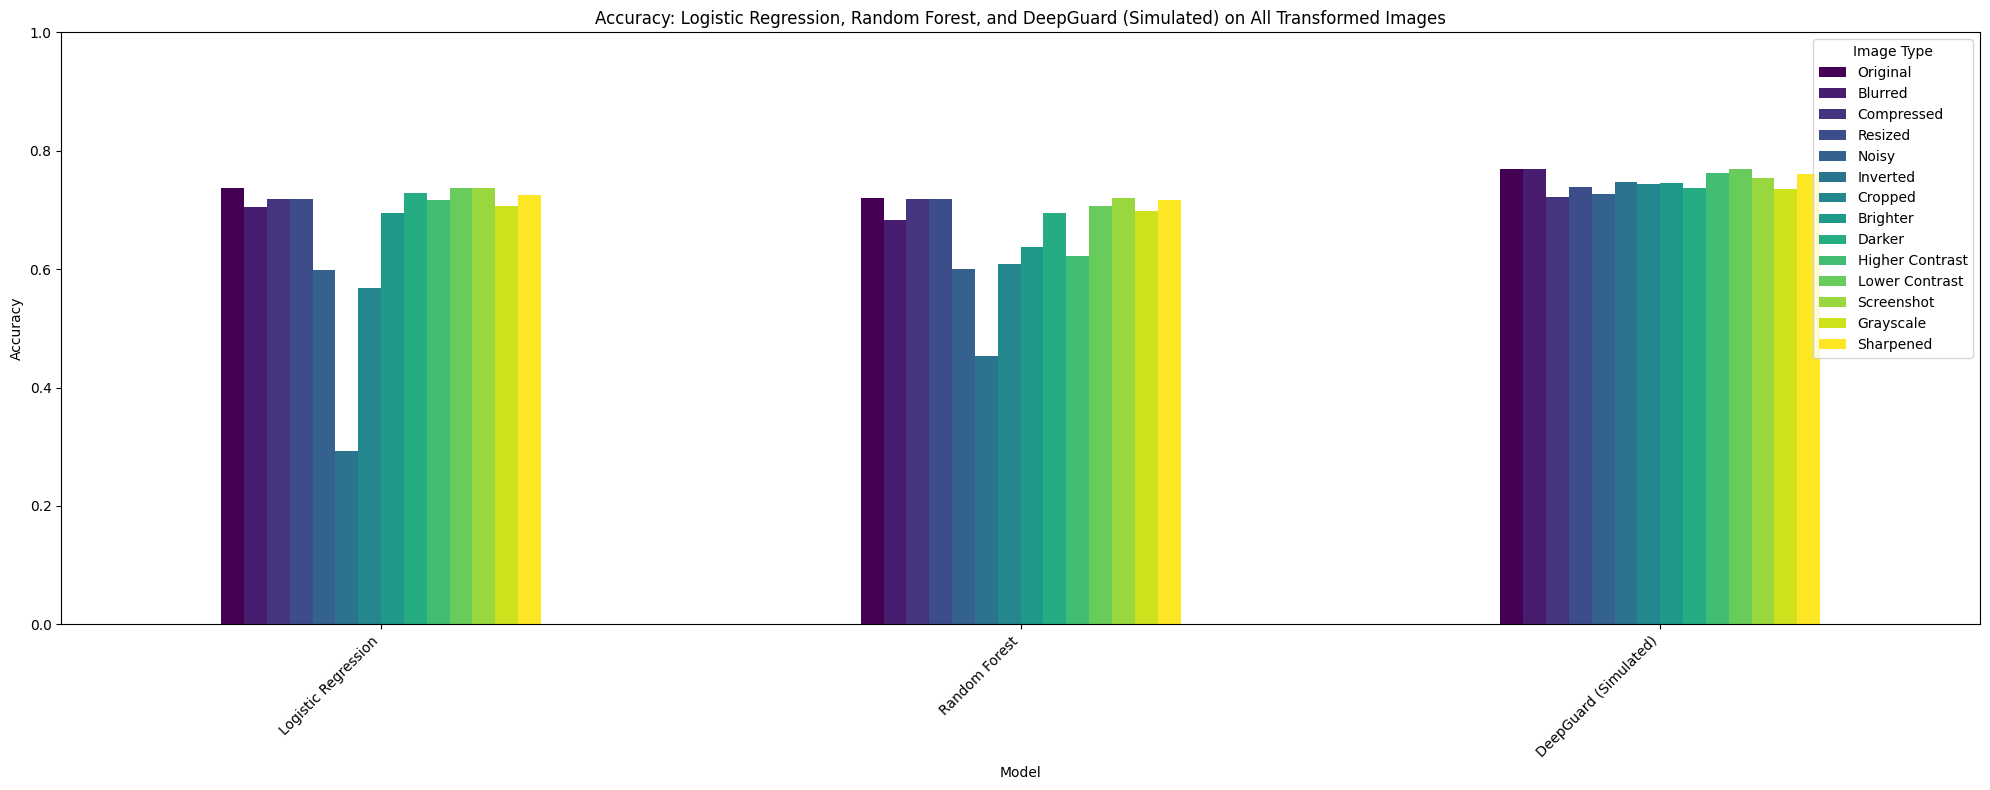

In [78]:
plt.figure(figsize=(20, 8))
results_df.loc[['Logistic Regression', 'Random Forest', 'DeepGuard (Simulated)']].plot(kind='bar', figsize=(20, 8), colormap='viridis')
plt.title('Accuracy: Logistic Regression, Random Forest, and DeepGuard (Simulated) on All Transformed Images')
plt.ylabel('Accuracy')
plt.xlabel('Model')
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Image Type')
plt.tight_layout()
plt.show()